In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

# 設定圖表風格
sns.set_theme(style="whitegrid")

# 模組化：建立讀取資料的 Function 展現工程習慣
def load_churn_data(file_path: str) -> pd.DataFrame:
    """
    讀取 Telco Churn 數據集並進行初步清理
    """
    try:
        df = pd.read_csv(file_path)
        print(f"✅ 成功載入資料！共 {df.shape[0]} 筆記錄，{df.shape[1]} 個欄位。")
        
        # 資料清洗：TotalCharges 欄位原本是字串，且包含空白字元，需轉為浮點數
        # 使用 errors='coerce' 將無法轉換的空白變成 NaN，然後填補為 0
        df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
        
        return df
    
    except FileNotFoundError:
        print(f"❌ 找不到檔案：{file_path}。請確認路徑是否正確。")
        return pd.DataFrame()
    except Exception as e:
        print(f"❌ 發生未預期的錯誤：{e}")
        return pd.DataFrame()

# 執行讀取 (請確保 csv 檔案與 notebook 在同一個資料夾，或替換為你的路徑)
df_churn = load_churn_data('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 預覽前五筆資料
df_churn.head()

✅ 成功載入資料！共 7043 筆記錄，21 個欄位。


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
import pandas as pd
import scipy.stats as stats

# 1. 準備一個空的 List
chi2_results = []

# 2. 【改良版】安全地抓取所有文字/類別欄位
# 一次把 'object', 'string', 'category' 三種可能的文字型態都抓進來
cat_df = df_churn.select_dtypes(include=['object', 'string', 'category'])

# 取得欄位名稱，並排除沒有預測意義的 customerID 以及目標變數 Churn 本身
categorical_cols = [col for col in cat_df.columns if col not in ['customerID', 'Churn']]

print(f"🔎 準備進行檢定的類別欄位有 {len(categorical_cols)} 個：\n{categorical_cols}\n")

# 3. 執行檢定
if len(categorical_cols) > 0:
    for col in categorical_cols:
        contingency_table = pd.crosstab(df_churn[col], df_churn['Churn'])
        chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
        
        chi2_results.append({
            '特徵': col,
            '卡方分數': round(chi2, 2),
            'P值': p_value
        })

    # 4. 轉成 DataFrame 並排序
    df_chi2_rank = pd.DataFrame(chi2_results)
    df_chi2_rank = df_chi2_rank.sort_values(by='卡方分數', ascending=False).reset_index(drop=True)

    print("🏆 類別型特徵 - 卡方檢定影響力排行榜 🏆")
    display(df_chi2_rank)
else:
    print("❌ 警告：依然沒有找到類別欄位，請檢查資料集狀態。")

🔎 準備進行檢定的類別欄位有 15 個：
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

🏆 類別型特徵 - 卡方檢定影響力排行榜 🏆


,特徵,卡方分數,P值
0,Contract,1184.60,5.863038e-258
1,OnlineSecurity,850.00,2.661150e-185
2,TechSupport,828.20,1.443084e-180
3,InternetService,732.31,9.571788e-160
4,PaymentMethod,648.14,3.682355e-140
5,OnlineBackup,601.81,2.079759e-131
6,DeviceProtection,558.42,5.505219e-122
7,StreamingMovies,375.66,2.667757e-82
8,StreamingTV,374.20,5.528994e-82
9,PaperlessBilling,258.28,4.073355e-58


In [20]:
query = """
SELECT 
    Contract AS '合約類型',
    PaymentMethod AS '付款方式',
    COUNT(customerID) AS '總用戶數',
    SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)  AS '流失客人',
    ROUND(SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)  / COUNT(customerID) *100,2) AS '流失率',
    SUM(CASE WHEN Churn='Yes' THEN MonthlyCharges ELSE 0 END) AS "損失的月營收 (Lost MRR)"
FROM df_churn,
GROUP BY Contract, PaymentMethod 
ORDER BY "流失率" DESC
"""

# 執行 SQL 並將結果轉回 DataFrame 顯示
df_churn_summary = duckdb.query(query).df()

# 顯示前五大重災區
df_churn_summary.head()

,合約類型,付款方式,總用戶數,流失客人,流失率,損失的月營收 (Lost MRR)
0,Month-to-month,Electronic check,1850,994.0,53.73,77315.60
1,Month-to-month,Bank transfer (automatic),589,201.0,34.13,15151.95
2,Month-to-month,Credit card (automatic),543,178.0,32.78,13335.15
3,Month-to-month,Mailed check,893,282.0,31.58,15044.40
4,One year,Electronic check,347,64.0,18.44,5826.80


In [21]:
import pandas as pd
import scipy.stats as stats

# 1. 建立列聯表 (Contingency Table) - 計算不同合約下，流失與未流失的人數
contingency_table = pd.crosstab(df_churn['Contract'], df_churn['Churn'])
print("【觀察到的實際人數】")
print(contingency_table)
print("=" * 40)

# 2. 進行卡方檢定
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"卡方統計量 (Chi2): {chi2:.4f}")
print(f"P 值 (P-value): {p_value:.4e}")

print("=" * 40)
if p_value < 0.05:
    print("✅ 結論：P 值 < 0.05，拒絕虛無假設。合約類型與客戶流失存在『極度顯著的關聯性』！")
else:
    print("❌ 結論：P 值 >= 0.05，合約類型與流失沒有顯著關聯。")

【觀察到的實際人數】
Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48
卡方統計量 (Chi2): 1184.5966
P 值 (P-value): 5.8630e-258
✅ 結論：P 值 < 0.05，拒絕虛無假設。合約類型與客戶流失存在『極度顯著的關聯性』！


In [22]:
import pandas as pd
import scipy.stats as stats

# 1. 建立列聯表 (Contingency Table) - 計算不同技術支援下，流失與未流失的人數
contingency_table = pd.crosstab(df_churn['TechSupport'], df_churn['Churn'])
print("【觀察到的實際人數】")
print(contingency_table)
print("=" * 40)

# 2. 進行卡方檢定
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"卡方統計量 (Chi2): {chi2:.4f}")
print(f"P 值 (P-value): {p_value:.4e}")

print("=" * 40)
if p_value < 0.05:
    print("✅ 結論：P 值 < 0.05，拒絕虛無假設。不同技術支援類型與客戶流失存在『極度顯著的關聯性』！")
else:
    print("❌ 結論：P 值 >= 0.05，合約類型與流失沒有顯著關聯。")

【觀察到的實際人數】
Churn                  No   Yes
TechSupport                    
No                   2027  1446
No internet service  1413   113
Yes                  1734   310
卡方統計量 (Chi2): 828.1971
P 值 (P-value): 1.4431e-180
✅ 結論：P 值 < 0.05，拒絕虛無假設。不同技術支援類型與客戶流失存在『極度顯著的關聯性』！


In [23]:
import pandas as pd
import scipy.stats as stats

# 1. 建立列聯表 (Contingency Table) - 計算不同網路類型下，流失與未流失的人數
contingency_table = pd.crosstab(df_churn['InternetService'], df_churn['Churn'])
print("【觀察到的實際人數】")
print(contingency_table)
print("=" * 40)

# 2. 進行卡方檢定
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"卡方統計量 (Chi2): {chi2:.4f}")
print(f"P 值 (P-value): {p_value:.4e}")

print("=" * 40)
if p_value < 0.05:
    print("✅ 結論：P 值 < 0.05，拒絕虛無假設。網路類型與客戶流失存在『極度顯著的關聯性』！")
else:
    print("❌ 結論：P 值 >= 0.05，合約類型與流失沒有顯著關聯。")

【觀察到的實際人數】
Churn              No   Yes
InternetService            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113
卡方統計量 (Chi2): 732.3096
P 值 (P-value): 9.5718e-160
✅ 結論：P 值 < 0.05，拒絕虛無假設。網路類型與客戶流失存在『極度顯著的關聯性』！


In [24]:
# Q3: 高風險用戶畫像 (多維度交叉分析)
query_profile = """
SELECT 
    Contract AS "合約類型",
    InternetService AS "網路類型",
    TechSupport AS "技術支援",
    COUNT(customerID) AS "總人數",
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS "流失人數",
    ROUND(SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(customerID), 2) AS "流失率 (%)"
FROM df_churn
-- 排除沒有購買網路服務的客群，避免干擾
WHERE InternetService != 'No' 
GROUP BY Contract, InternetService, TechSupport
-- 加上 HAVING 條件，排除人數太少（例如低於 100 人）的極端小眾群體，確保統計有代表性
HAVING COUNT(customerID) > 100 
ORDER BY "流失率 (%)" DESC
LIMIT 5;
"""

# 執行 SQL 並將結果轉回 DataFrame 顯示
df_high_risk_profile = duckdb.query(query_profile).df()

# 顯示前五大高風險客群畫像
df_high_risk_profile

,合約類型,網路類型,技術支援,總人數,流失人數,流失率 (%)
0,Month-to-month,Fiber optic,No,1796,1033.0,57.52
1,Month-to-month,Fiber optic,Yes,332,129.0,38.86
2,Month-to-month,DSL,No,884,317.0,35.86
3,Month-to-month,DSL,Yes,339,77.0,22.71
4,One year,Fiber optic,Yes,226,46.0,20.35


🏆 決策樹選出的 Top 5 關鍵流失特徵：
----------------------------------------
Top 1: tenure (重要性分數: 0.4460)
Top 2: InternetService_Fiber optic (重要性分數: 0.3462)
Top 3: TotalCharges (重要性分數: 0.0365)
Top 4: OnlineSecurity_No internet service (重要性分數: 0.0299)
Top 5: PaymentMethod_Electronic check (重要性分數: 0.0274)
----------------------------------------


C:\Users\winka\AppData\Local\Temp\ipykernel_12412\225511692.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_features.values, y=top_5_features.index, palette="viridis")


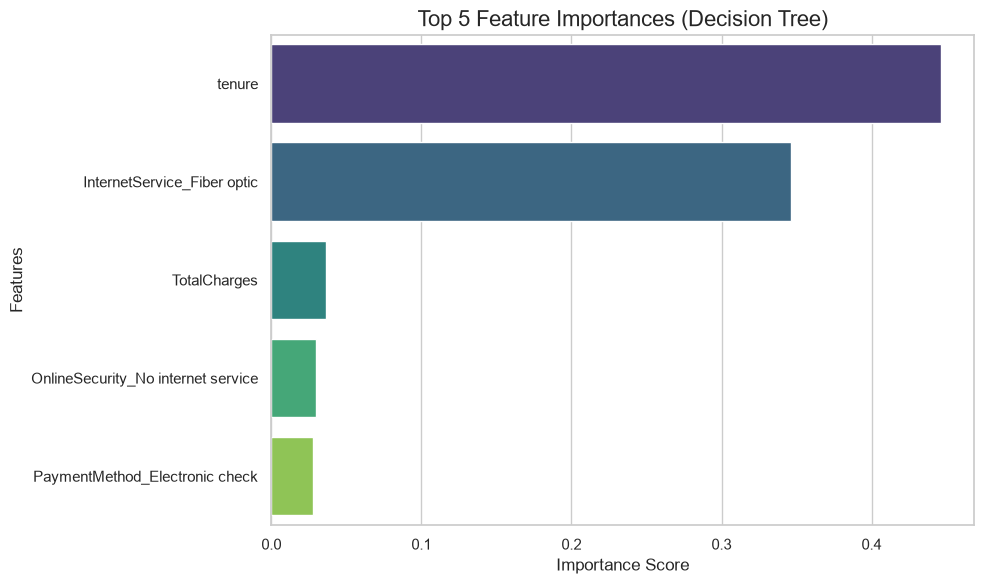

In [25]:
# 引入機器學習套件
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 資料預處理 (Data Preprocessing)
# 複製一份資料避免改到原始 DataFrame
df_ml = df_churn.copy()

# 把目標變數 'Churn' 的 Yes/No 轉換成數字 1/0
df_ml['Churn'] = df_ml['Churn'].map({'Yes': 1, 'No': 0})

# 丟掉對預測沒有幫助的 customerID
df_ml = df_ml.drop('customerID', axis=1)

# 把所有「類別變數 (文字)」轉換成「虛擬變數 (0與1)」(One-Hot Encoding)
# drop_first=True 是為了避免共線性陷阱
X = pd.get_dummies(df_ml.drop('Churn', axis=1), drop_first=True)
y = df_ml['Churn']

# 2. 建立並訓練決策樹模型
# 設定 max_depth=5 避免樹長得太深（過擬合），我們只要看最關鍵的幾層
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X, y)

# 3. 提取特徵重要性 (Feature Importance)
feature_importances = pd.Series(dt_model.feature_importances_, index=X.columns)

# 排序並取出 Top 5
top_5_features = feature_importances.sort_values(ascending=False).head(5)

print("🏆 決策樹選出的 Top 5 關鍵流失特徵：")
print("-" * 40)
for i, (feature, score) in enumerate(top_5_features.items(), 1):
    print(f"Top {i}: {feature} (重要性分數: {score:.4f})")
print("-" * 40)

# 4. 畫出長條圖，這張圖非常適合放在 GitHub 或 PPT 裡！
plt.figure(figsize=(10, 6))
sns.barplot(x=top_5_features.values, y=top_5_features.index, palette="viridis")
plt.title('Top 5 Feature Importances (Decision Tree)', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()